## Manuel Ramallo, Lucía Pérez, Alexandre Lorenzo

# Implementación dunha arquitectura MLP modular


In [12]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 -q
!pip3 install scikit-image -q
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split

import copy
from skimage.feature import hog
from skimage.color import rgb2gray

import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


torch.manual_seed(1)
random.seed(1)
np.random.seed(1)

In [13]:

def plot_confusion_matrix(y_true, y_pred, labels_map):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 10))
    plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, labels_map.values(), rotation=45)
    plt.yticks(tick_marks, labels_map.values())

    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, f"{conf_matrix[i, j]}",
                    horizontalalignment="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('Clase real')
    plt.xlabel('Clase predicida')
    plt.show()

def get_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Neste apartado definirase unha arquitectura de MLP (Perceptrón Multicapa) xenérica con PyTorch que xera un modelo modular a partir dunha serie de parámetros introducidos:


*   Número de neuronas da capa de entrada
*   Número de neuronas da capa de saída
*   Configuración de capas ocultas: Unha lista que especifica o número de neuronas para cada nivel intermedio.

A partir dos parámetros, constrúense as capas dinámicamente.


A función de activación está establecida por defecto: a función RELU. O motivo é a súa capacidade para crear unha representación máis eficiente e lixeira da rede, eliminando os valores negativos, ademais da súa facilidade para converxer.





In [14]:
class MLP(nn.Module):

    def __init__(self, input_neurons, output_neurons, hidden_layers):

        super(MLP, self).__init__()
        self.flatten = nn.Flatten()

        # Lista para almacenar capas
        self.layers = nn.ModuleList()

        # Engadimos a primeira capa (Entrada -> Primeira capa oculta)
        # Se a lista de ocultas está vacía, conectamos entrada con saída directamente
        if len(hidden_layers) > 0:
            self.layers.append(nn.Linear(input_neurons, hidden_layers[0]))

            # Engadimos as capas ocultas intermedias
            # Percorremos dende a primeira oculta ata a penúltima
            for i in range(len(hidden_layers) - 1):
                self.layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))

            # Engadimos a última capa (Última oculta -> Saída)
            self.layers.append(nn.Linear(hidden_layers[-1], output_neurons))
        else:
            # Caso especial: Se non hai capas ocultas
            self.layers.append(nn.Linear(input_neurons, output_neurons))

        # Definimos as funcións de activación
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):

        x = self.flatten(x)
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.relu(x)

        return x

### Implementación CNN modular

A continuación preséntase a implementación dunha rede convolucional neuronal (CNN) modular. Esta rede está formada por unha serie de capas convolucionais seguidas por unha capa totalmente conectada, correspondente a un MLP.
A flexibilidade da implementación reside en que crea dinámicamente distintos números e configuracións de capas dependendo dos parámetros cos que sexa inicializada, que son os seguintes:


*   Número de canles de entrada.

*   Número de capas convolucionais. Cada capa convolucional está formada por unha operación de convolución seguida por unha función de activación (RELU) e unha operación de pooling.
*   Número de filtros da primeira capa convolucional. Cada capa terá o dobre de filtros que a anterior, comezando por este valor que se lle asigna á primeira.


*   Tamaño do kernel convolucional, asumindo que será cadrado.


*   Uso de normalización por lotes. Un valor booleano que indica si se aplica esta operación en cada capa convolucional entre a operación de convolución e a función de activación.
*   Número de neuronas das capas ocultas do MLP: Unha lista que especifica o número de neuronas para cada nivel intermedio.


*   Número de neuronas da capa de saída.

A diferencia do perceptrón multicapa aislado, neste CNN non se debe especificar o número de neuronas de entrada do MLP, pois ven dado pola natureza das capas de convolución e calcúlase dinámicamente multiplicando o número de canles de saída pola anchura e altura de cada unha das canles.

A construción do CNN divideuse nos dous bloques claramente diferenciados en distintas clases de python, integradas na clase xeral, ModuleCNN, que as instancia e as conecta usando a función flatten de PyTorch.



In [33]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, num_conv_layers, first_layer_filters, kernel_size, norm):
        super(ConvBlock, self).__init__()

        layers = []
        in_ch = in_channels

        for i in range(num_conv_layers):
            out_ch = first_layer_filters * (2 ** i)

            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size, padding=1))

            if norm:
                layers.append(nn.BatchNorm2d(out_ch))

            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            in_ch = out_ch  # Actualizo los in_channels para la siguiente capa

        self.block = nn.Sequential(*layers)
        out_ch = first_layer_filters * (2 ** (num_conv_layers - 1))
        self.last_filters = out_ch

    def forward(self, x):
        return self.block(x)


class FCBlock(nn.Module):
    def __init__(self, in_features, hidden_mlp_layers, output_neurons):
        super(FCBlock, self).__init__()

        layers = []
        for hidden_size in hidden_mlp_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size

        layers.append(nn.Linear(in_features, output_neurons))
        # Sin Softmax (CrossEntropyLoss lo incluye internamente)

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [16]:
class ModuleCNN(nn.Module):
    def __init__(self, init_h, init_w, in_channels, num_conv_layers, first_layer_filters,
                 kernel_size, norm, hidden_mlp_layers, output_neurons):
        super(ModuleCNN, self).__init__()

        self.conv = ConvBlock(in_channels, num_conv_layers, first_layer_filters, kernel_size, norm)

        # Cálculo a mano del tamaño de la salida del bloque convolucional (alternativa al dummy)
        h, w = init_h, init_w
        for _ in range(num_conv_layers):
            # conv
            h = (h+2) - kernel_size + 1 # padding de 1, stride de 1
            w = (w+2) - kernel_size + 1
            # pooling
            h = h //2
            w = w //2
        flat_size = self.conv.last_filters * h * w

        self.fc = FCBlock(flat_size, hidden_mlp_layers, output_neurons)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [17]:
cnn = ModuleCNN(init_h=160, init_w=160, in_channels=3, num_conv_layers=5, first_layer_filters=8,
                kernel_size=3, norm=True, hidden_mlp_layers=[128], output_neurons=10)
print(f"O modelo ten {get_parameters(cnn):,} parámetros")

O modelo ten 509,898 parámetros


## Optimización de MLP nun problema real

### Extración de datasets

A continuación evaluaranse estas dúas implementacións de redes neuronais realizadas. Para iso empregarase o conxunto de datos Imagginette, referente a un problema de clasificación con 10 clases de saída.

Usarase para os dous entrenamentos o método dos dataloaders con un tamaño de lote fixo de 8 exemplos. A resolución tomada das imaxes é de 160px. Debido ao elevado número de parámetros dos modelos resultantes optouse por reescalar as imaxes a 80x80 píxeles. Un CNN razonablemente sencillo incializado a modo de proba (unha soa capa oculta no MLP, 8 filtros na primeira capa e 5 capas de convolución) constaba de máis de medio millón de parámetros.

In [18]:
full_train_data = datasets.Imagenette(root="data/", split="train", size="160px", download=True, transform=transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
]))
test_data       = datasets.Imagenette(root="data/", split="val",   size="160px", download=True, transform=transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
]))
print(f"Total de imaxes de adestramento: {len(full_train_data)}")
print(f"Total de imaxes de test: {len(test_data)}")
train_size = int(0.85 * len(full_train_data))
val_size   = len(full_train_data) - train_size
train_dataset, val_dataset = random_split(full_train_data, [train_size, val_size])

batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size, shuffle=False)

print(f"Número de lotes de adestramento: {len(train_dataloader)}")
print(f"Número de lotes de validación: {len(val_dataloader)}")
print(f"Número de lotes de test: {len(test_dataloader)}")
for batch_imgs, batch_labels in train_dataloader:
    print(f"Tamaño das imaxes: {batch_imgs.size()} - Etiquetas: {batch_labels}")
    break # Paramos o bucle, xa que só queremos ver un lote

Total de imaxes de adestramento: 9469
Total de imaxes de test: 3925
Número de lotes de adestramento: 1006
Número de lotes de validación: 178
Número de lotes de test: 491
Tamaño das imaxes: torch.Size([8, 3, 80, 80]) - Etiquetas: tensor([5, 3, 5, 0, 4, 9, 7, 7])


Na seguinte celda defínense as distintas configuracións que se adoptarán para as redes neuronais.

En primeiro lugar, o MLP acepta menos flexibilidade de argumentos, sendo o principal parámetro a lista de capas internas. Incluíronse opcións con unha soa capa (512, 256), dúas ([1024, 512], [512, 256]) e ata tres([1024, 512, 256]).

O número de neuronas de entrada está fixo a 19200 e o de saída a 10.

Tamén se incluiu unha variación sobre a tasa de aprendizaxe estándar (1e-3). Sobre dúas configuracións xa existentes de MLP optouse por probar cunha tasa de 1e-2. Apriori debería ser demasiado lenta na converxencia pero estudiarase o seu resultado. Pode resultar eficaz no caso de que o modelo tenda ao sobreaxuste sobre este conxunto de datos.

Por último, a función optimizadora dos pesos da rede decideuse manter constante co método Adam. A súa principal ventaxa fronte ao método clásico SGD é que personaliza a tasa de aprendizaxe a cada parámetro, evitando que os pesos caian en mínimos locais e proporcionando, xeralmente, unha converxencia eficaz en menos épocas ao usar as actualizacións anteriores para determinar a magnitude do aprendizaxe. A nivel de rendemento non se atoparon ventaxas teóricas da estratexia SGD e, tendo en conta o elevado tempo que necesitan estes modelos para entrenarse, decideuse simplemente non ter en conta a variación desde parámetro e usar a estratexia Adam como constante.

En canto ás redes convolucionais, o *pool* de parámetros a variar e moito máis amplo, polo que houbo que decidir cales variar e cales manter como constantes.

Como norma xeral, decidiuse tratar de variar os parámetros que otorgan á rede de diferenzas en canto á capacidade lóxica e a abstración. É dicir, modificar o número de capas de colvolución, número de filtros e diseño da capa totalmente conectada. Por último, ao igual que no caso do MLP, decideuse explorar o learning rate en dúas configuracións, esta vez dismunuíndoo.

Aínda así, non se adoptou unha estratexia de grid como tal, si non que se tomou unha configuración o máis xenérica posible e exploráronse para cada parámetro valores que lle dan á rede máis profundidade nese ámbito.

Por outro lado, mantivéronse constantes os parámetros da convolución (tamaño do kernel, padding) e do pooling (tamaño do pooling).

Por último, debatíronse outros parámetros do adestramento que finalmente tamén se tomaron como constantes: o número de épocas fixouse a 15 despois dunha serie de probas rápidas onde o mecanismo do early stopping freaba a execución antes de chegar a este límite un bo porcentaxe de veces, e a mellora a partir de aquí, se é que había, disminuía en comparación coas épocas anteriores.

Por último, o número de lotes, como xa se mencionou antes, estableceuse fixo a 8 porque non é un parámetro que baixo a teoría sexa determinante precisaría moitos recursos computacionales estudar o seu impacto.


In [25]:
mlps = [{"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[1024, 512, 256]), "lr": 1e-3, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512, 256]), "lr": 1e-2, "optimizer": "Adam"},
        {"model": MLP(input_neurons=80*80*3, output_neurons=10, hidden_layers=[512]), "lr": 1e-2, "optimizer": "Adam"},
]

configs_cnn = [
    # ── Configuración base
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Máis profundidade convolucional
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 5, "first_layer_filters": 8,  "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Máis filtros
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-3},

    # ── Ampliación a dúas capas FC
    {"cnn_params": {"num_conv_layers": 3, "first_layer_filters": 8,  "hidden_mlp_layers": [256, 128]},  "lr": 1e-3},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [256, 128]},  "lr": 1e-3},

    # ── Learning rate máis baixo
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-4},
    {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [256, 128]},  "lr": 1e-4},
]


loss_fn = nn.CrossEntropyLoss()

#### Funcións de adestramento e test reutilizables

In [26]:
def train(dataloader, model, loss_fn, optimizer):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()
    # Iteramos sobre os lotes
    n_batch = 0
    for batch_imgs, batch_labels in dataloader:
        # Obtemos as predicións para o lote actual
        batch_predicted_probabilities = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(batch_predicted_probabilities, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Cada 100 lotes, imprimimos a perda e o progreso
        if n_batch % 200 == 0 and n_batch > 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss

def test(dataloader, model):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_loss,test_predicted_classes, test_true_classes

### Bucles de execución

A estratexia de adestramento tomada é idéntica para ambos modelos.

Realízase un bucle xeral onde en cada iteración confecciónase un modelo cos parámetros impostos. Dentro realízase o bucle de adestramento de 15 épocas co mecanismo de early stopping activado. En cada iteración úsase o conxunto de train para adestrar a rede e o de validación para obter un valor de perda medio. O estado que menor perda produceu gárdase para unha vez finalizan as épocas.

A perda media desta instancia do modelo é comparada coa mellor versión atopada de entre o resto de configuración e, en caso de ter un valor menor de perda, tómase como o modelo óptimo provisional.

Adicionalmente, todos os modelos son evaluados fronte o conxunto de test para obter as métricas de rendemento, aínda que estas non sexan usadas para elixir o que será tomado como modelo óptimo.

#### Execución modelos MLP

In [27]:
best_global_val_loss = float('inf')
best_global_model    = None
best_global_cfg      = None
results_mlp = []

for config in mlps:
    mlp = config["model"]
    learning_rate = config["lr"]
    optimizer_name = config["optimizer"]
    train_losses_mlp = []
    val_losses_mlp = []
    epochs = 15
    best_val_loss = float('inf')
    best_model = None
    patience = 3
    current_patience = 0

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(mlp.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate)

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train_loss = train(train_dataloader, mlp, loss_fn, optimizer)
        train_losses_mlp.append(train_loss.item())

        val_loss = test(val_dataloader, mlp)[0]
        val_losses_mlp.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(mlp.state_dict())
            current_patience = 0
        else:
            current_patience += 1
            if current_patience >= patience:
                print("Early stopping")
                break

    mlp.load_state_dict(best_model)

    # Evaluar en test
    _, test_predicted, test_true = test(test_dataloader, mlp)
    acc       = accuracy_score(test_true, test_predicted)
    precision = precision_score(test_true, test_predicted, average='macro')
    recall    = recall_score(test_true, test_predicted, average='macro')
    f1        = f1_score(test_true, test_predicted, average='macro')

    results_mlp.append({
        "optimizer":     optimizer_name,
        "lr":            learning_rate,
        "params_mlp":    get_parameters(mlp),
        "val_loss":      best_val_loss,
        "accuracy":      acc,
        "precision":     precision,
        "recall":        recall,
        "f1":            f1,
        "train_losses":  train_losses_mlp,
        "val_losses":    val_losses_mlp,
    })

    # Comprobamos se é o mellor modelo global
    if best_val_loss < best_global_val_loss:
        best_global_val_loss = best_val_loss
        best_global_model    = copy.deepcopy(mlp.state_dict())
        best_global_cfg      = config
        print(f"Novo mellor modelo global (val_loss={best_val_loss:.6f})")

# Tabla resumen
results_mlp_df = pd.DataFrame(results_mlp).drop(columns=["train_losses", "val_losses"])
print(results_mlp_df)

Epoch 1
-------------------------------
perda: 2.410516  [ 1600/ 8048]
perda: 1.986755  [ 3200/ 8048]
perda: 2.202961  [ 4800/ 8048]
perda: 2.176909  [ 6400/ 8048]
perda: 2.003423  [ 8000/ 8048]
Perda media: 0.264909 Accuracy: 21.4%

Epoch 2
-------------------------------
perda: 1.798727  [ 1600/ 8048]
perda: 1.929380  [ 3200/ 8048]
perda: 2.159074  [ 4800/ 8048]
perda: 2.248571  [ 6400/ 8048]
perda: 1.927007  [ 8000/ 8048]
Perda media: 0.251247 Accuracy: 31.1%

Epoch 3
-------------------------------
perda: 2.025447  [ 1600/ 8048]
perda: 2.115107  [ 3200/ 8048]
perda: 2.600620  [ 4800/ 8048]
perda: 2.568069  [ 6400/ 8048]
perda: 1.936688  [ 8000/ 8048]
Perda media: 0.263664 Accuracy: 25.7%

Epoch 4
-------------------------------
perda: 1.971510  [ 1600/ 8048]
perda: 2.274349  [ 3200/ 8048]
perda: 2.314343  [ 4800/ 8048]
perda: 1.139705  [ 6400/ 8048]
perda: 1.542086  [ 8000/ 8048]
Perda media: 0.244919 Accuracy: 31.0%

Epoch 5
-------------------------------
perda: 2.388940  [ 1600/

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


perda: 1.862275  [ 1600/ 8048]
perda: 2.430691  [ 3200/ 8048]
perda: 1.550994  [ 4800/ 8048]
perda: 2.423756  [ 6400/ 8048]
perda: 2.313852  [ 8000/ 8048]
Perda media: 0.251591 Accuracy: 30.5%

Epoch 2
-------------------------------
perda: 1.363779  [ 1600/ 8048]
perda: 1.981360  [ 3200/ 8048]
perda: 1.650401  [ 4800/ 8048]
perda: 1.973386  [ 6400/ 8048]
perda: 1.919098  [ 8000/ 8048]
Perda media: 0.255599 Accuracy: 27.9%

Epoch 3
-------------------------------
perda: 2.012131  [ 1600/ 8048]
perda: 2.621830  [ 3200/ 8048]
perda: 2.386164  [ 4800/ 8048]
perda: 1.673977  [ 6400/ 8048]
perda: 1.540015  [ 8000/ 8048]
Perda media: 0.238330 Accuracy: 33.3%

Epoch 4
-------------------------------
perda: 2.179760  [ 1600/ 8048]
perda: 1.797141  [ 3200/ 8048]
perda: 1.739169  [ 4800/ 8048]
perda: 2.248583  [ 6400/ 8048]
perda: 1.811926  [ 8000/ 8048]
Perda media: 0.233939 Accuracy: 36.5%

Epoch 5
-------------------------------
perda: 2.374609  [ 1600/ 8048]
perda: 2.056519  [ 3200/ 8048]
pe

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


perda: 2.300808  [ 1600/ 8048]
perda: 2.281910  [ 3200/ 8048]
perda: 2.310905  [ 4800/ 8048]
perda: 2.338568  [ 6400/ 8048]
perda: 2.286430  [ 8000/ 8048]
Perda media: 0.288686 Accuracy: 10.8%

Epoch 2
-------------------------------
perda: 2.311398  [ 1600/ 8048]
perda: 2.301284  [ 3200/ 8048]
perda: 2.298250  [ 4800/ 8048]
perda: 2.307759  [ 6400/ 8048]
perda: 2.325189  [ 8000/ 8048]
Perda media: 0.288773 Accuracy: 10.6%

Epoch 3
-------------------------------
perda: 2.297575  [ 1600/ 8048]
perda: 2.294296  [ 3200/ 8048]
perda: 2.351774  [ 4800/ 8048]
perda: 2.319384  [ 6400/ 8048]
perda: 2.304188  [ 8000/ 8048]
Perda media: 0.288557 Accuracy: 10.3%

Epoch 4
-------------------------------
perda: 2.263297  [ 1600/ 8048]
perda: 2.294461  [ 3200/ 8048]
perda: 2.294653  [ 4800/ 8048]
perda: 2.277669  [ 6400/ 8048]
perda: 2.348390  [ 8000/ 8048]
Perda media: 0.288731 Accuracy: 10.8%

Epoch 5
-------------------------------
perda: 2.314687  [ 1600/ 8048]
perda: 2.325813  [ 3200/ 8048]
pe

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Execución modelos CNN

In [31]:
def train_with_early_stopping_cnn(model, train_dataloader, val_dataloader,
                               epochs=15, patience=3, lr=1e-3, optimizer_name="Adam"):
    loss_fn   = nn.CrossEntropyLoss()
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss    = float('inf')
    best_model_state = None
    current_patience = 0
    train_losses, val_losses = [], []

    for t in range(epochs):
        print(f"\nEpoch {t+1}/{epochs}\n{'-'*35}")
        train_loss = train(train_dataloader, model, loss_fn, optimizer)
        train_losses.append(train_loss.item())

        val_loss, _, _ = test(val_dataloader, model)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            current_patience = 0
            print("Mellor modelo gardado")
        else:
            current_patience += 1
            print(f"  Paciencia: {current_patience}/{patience}")
            if current_patience >= patience:
                print(f"Early stopping activado")
                break

    model.load_state_dict(best_model_state)
    return model, best_val_loss, train_losses, val_losses

In [32]:
best_global_val_loss = float('inf')
best_global_model    = None
results_cnn = []

for cfg in configs_cnn:
    print(f"\n{'='*50}")
    print(f"Config: {cfg}")

    model = ModuleCNN(init_h=80, init_w=80, in_channels=3,
                kernel_size=3, norm=True, output_neurons=10, **cfg["cnn_params"])
    print(f"Parámetros: {get_parameters(model):,}")
    model, best_val_loss, train_losses, val_losses = train_with_early_stopping_cnn(
        model, train_dataloader, val_dataloader, epochs=20, patience=3, lr=cfg["lr"]
    )

    # Evaluar en test
    loss_fn = nn.CrossEntropyLoss()
    _, test_predicted, test_true = test(test_dataloader, model)
    acc = accuracy_score(test_true, test_predicted)
    precision = precision_score(test_true, test_predicted, average='macro')
    recall = recall_score(test_true, test_predicted, average='macro')
    f1  = f1_score(test_true, test_predicted, average='macro')

    results_cnn.append({**cfg, "params": get_parameters(model),
                    "val_loss": best_val_loss, "accuracy": acc, "precision": precision,
                    "recall": recall, "f1": f1, "train_losses": train_losses, "val_losses": val_losses})

    # Actualizar mejor modelo global (comparando por val_loss)
    if best_val_loss < best_global_val_loss:
        best_global_val_loss = best_val_loss
        best_global_model    = copy.deepcopy(model.state_dict())
        print(f"Novo mellor modelo global (val_loss={best_val_loss:.6f})")
        best_global_cfg = cfg

# Mostrar tabla resumen
results_cnn_df = pd.DataFrame(results_cnn).drop(columns=["train_losses", "val_losses"])
print(results_cnn_df)


Config: {'cnn_params': {'num_conv_layers': 3, 'first_layer_filters': 8, 'hidden_mlp_layers': [128]}, 'lr': 0.001}
Parámetros: 417,162

Epoch 1/20
-----------------------------------
perda: 1.863139  [ 1600/ 8048]
perda: 1.482155  [ 3200/ 8048]
perda: 1.762436  [ 4800/ 8048]
perda: 0.918777  [ 6400/ 8048]
perda: 0.995990  [ 8000/ 8048]
Perda media: 0.176851 Accuracy: 51.4%

Mellor modelo gardado

Epoch 2/20
-----------------------------------
perda: 1.438263  [ 1600/ 8048]
perda: 0.607915  [ 3200/ 8048]
perda: 1.518617  [ 4800/ 8048]
perda: 1.430914  [ 6400/ 8048]
perda: 1.263999  [ 8000/ 8048]
Perda media: 0.151164 Accuracy: 59.1%

Mellor modelo gardado

Epoch 3/20
-----------------------------------
perda: 0.576042  [ 1600/ 8048]
perda: 0.858330  [ 3200/ 8048]
perda: 1.061576  [ 4800/ 8048]
perda: 1.750704  [ 6400/ 8048]
perda: 1.128312  [ 8000/ 8048]
Perda media: 0.157265 Accuracy: 58.5%

  Paciencia: 1/3

Epoch 4/20
-----------------------------------
perda: 0.741722  [ 1600/ 8048]

## VISUALIZACIÓN DE RESULTADOS

Neste apartado exporanse o resultados obtidos en forma de táboas e gráficas, comezando por un resumo de cada configuración adestrada, a súa perda e as súas métricas de rendemento fronte ao conxunto de test.



In [34]:
results_cnn_df

,cnn_params,lr,params,val_loss,accuracy,precision,recall,f1
0,"{'num_conv_layers': 3, 'first_layer_filters': ...",0.0010,417162,0.128766,0.660637,0.667025,0.661750,0.658754
1,"{'num_conv_layers': 4, 'first_layer_filters': ...",0.0010,230986,0.111686,0.695796,0.706598,0.697132,0.692901
2,"{'num_conv_layers': 5, 'first_layer_filters': ...",0.0010,165834,0.116812,0.700637,0.706731,0.700888,0.698127
3,"{'num_conv_layers': 3, 'first_layer_filters': ...",0.0010,844426,0.124195,0.634140,0.665662,0.636980,0.626682
4,"{'num_conv_layers': 4, 'first_layer_filters': ...",0.0010,508938,0.107166,0.718981,0.722708,0.720381,0.715016
5,"{'num_conv_layers': 3, 'first_layer_filters': ...",0.0010,859786,0.130868,0.652994,0.666837,0.654539,0.655129
6,"{'num_conv_layers': 4, 'first_layer_filters': ...",0.0010,951562,0.111168,0.693758,0.705125,0.696390,0.688460
7,"{'num_conv_layers': 4, 'first_layer_filters': ...",0.0001,508938,0.112830,0.697070,0.708502,0.696467,0.696695
8,"{'num_conv_layers': 4, 'first_layer_filters': ...",0.0001,951562,0.107867,0.706497,0.710873,0.707140,0.703992


In [35]:
results_mlp_df

,optimizer,lr,params_mlp,val_loss,accuracy,precision,recall,f1
0,Adam,0.001,4918026,0.234000,0.322803,0.325036,0.324369,0.291639
1,Adam,0.001,9836042,0.228772,0.357707,0.372198,0.359892,0.339340
2,Adam,0.001,20191754,0.214501,0.396943,0.392381,0.399080,0.380813
3,Adam,0.001,9964810,0.216095,0.390573,0.413331,0.392293,0.385719
4,Adam,0.001,20320522,0.218086,0.377070,0.372900,0.380343,0.357574
5,Adam,0.010,9964810,0.288256,0.090955,0.009096,0.100000,0.016674
6,Adam,0.010,9836042,0.288501,0.098599,0.009860,0.100000,0.017950


Os modelos óptimos foron obtidos ca seguinte combinación de parámetros:


---



*   MPL: {"model": MLP(input_neurons=80 * 80 * 3, output_neurons=10, hidden_layers=[1024, 512]), "lr": 1e-3

O conxunto de test obtivo un accuracy do 39,6%


---



*   CNN: {"cnn_params": {"num_conv_layers": 4, "first_layer_filters": 16, "hidden_mlp_layers": [128]},       "lr": 1e-3}

O Conxunto de test obtivo un accuracy do 71,9%


---


Tomarase o accuracy como única medida de rendemento incluida nas gráficas porque as clases de salida están perfectamente balanceadas e esta medida é totalmente representativa.



A continuación, amósanse gráficas da progresión temporal da perda media obtida en cada época, tanto no conxunto de adestramento coma no de validación

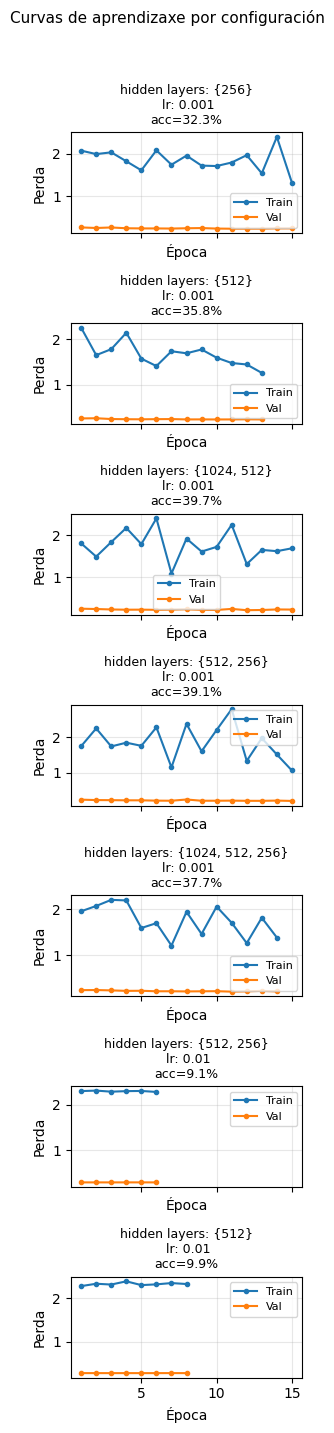

In [51]:
hidden_layers=[{256},{512},{1024,512},{512,256},{1024,512,256},{512,256},{512}]
n = len(results_mlp)
fig, axes = plt.subplots(n, 1, figsize=(3, 2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, r, layers in zip(axes, results_mlp, hidden_layers):
    epochs_ran = range(1, len(r["train_losses"]) + 1)
    ax.plot(epochs_ran, r["train_losses"], label="Train", marker="o", markersize=3)
    ax.plot(epochs_ran, r["val_losses"],   label="Val",   marker="o", markersize=3)
    ax.set_title(
        f"hidden layers: {layers}\n"
        f" lr: {r['lr']}\n"
        f"acc={r['accuracy']*100:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("Perda")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizaxe por configuración", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Nestas gráficas correspondentes ao modelos MLP adestrados podemos ver tendencias de mellora bastante pobres nos valores do erro de adestramento. A perda redúcese en escala moi pequena dende as primeiras iteracións e hai moitos picos de perdas. Aínda que non foron os que mellor resultado obtiveron, os modelos cuha soa capa oculta si que presentan menos picos de perdas e unha tendencia máis lineal.

Por outra parte, os modelos coa tasa de aprendizaxe máis baixa non estiveron nin cerca de converxer.

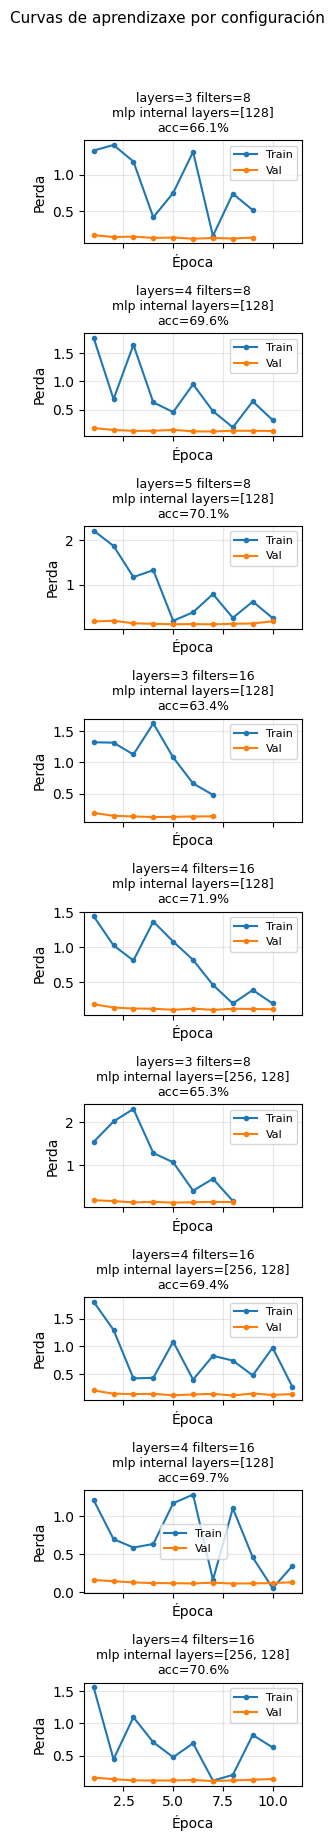

In [52]:
n = len(results_cnn)
fig, axes = plt.subplots(n, 1, figsize=(3, 2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, r in zip(axes, results_cnn):
    epochs_ran = range(1, len(r["train_losses"]) + 1)
    ax.plot(epochs_ran, r["train_losses"], label="Train", marker="o", markersize=3)
    ax.plot(epochs_ran, r["val_losses"],   label="Val",   marker="o", markersize=3)
    ax.set_title(
        f"layers={r['cnn_params']['num_conv_layers']} filters={r['cnn_params']['first_layer_filters']}\n"
        f"mlp internal layers={r['cnn_params']['hidden_mlp_layers']}\n"
        f"acc={r['accuracy']*100:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("Perda")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizaxe por configuración", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Os resultados dos modelos CNN tamén presentan saltos nos valores de perda obtidos. De feito, en todas as configuracións activouse o early stopping.
Distintas configuracións con diferentes profundidades obtiveron resultados moi similares, sin que destacase ningunha sobre o resto. Neste caso, a tasa de aprendizaxe alta sí que estivo á altura. Tamén hai que ter en conta que o optimizador Adam adapta este valor dinámicamente polo que non ten todo o impacto que cabe esperar.

Enfrentando estes resultados, hai unha clara melloría no uso das redes convolucionais fronte a un MLP simple. A accuracy obtida co mellor modelo do CNN, aínda sin ser un valor extremadamente alto, supera con creces ao modelo óptimo do perceptrón (71,9 fronte a 39,6 por cento).